#### Kaggle accounts:
WangPeifeng-wangpf114514<br>
LiuMingzheng-lumenl<br>
XuMinghao-xuminhao1011

# I. Abstract

This project employs the DistilBERT pre-trained model to accomplish text sentiment classification tasks. The workflow encompasses data reading and cleansing, hierarchical validation set partitioning, and utilises the DistilBERT tokeniser for batch encoding and padding of text, thereby constructing a TensorFlow data pipeline. The model loads the DistilBERT architecture and adapts its output layer for classification tasks. It is compiled using a sparse cross-entropy loss function with label smoothing and an Adam optimiser. An early stopping strategy is implemented during training to prevent overfitting, with fine-tuning completed within three epochs.

# II. Data Analysis

Analysis of the training dataset (train.csv) reveals that it comprises 386,809 samples categorised into six sentiment label classes.

| Label | Count  | Percentage |
|:------|:-------|:-----------|
| 0     | 112,464 | 29.07%     |
| 1     | 130,914 | 33.84%     |
| 2     | 32,067  | 8.29%      |
| 3     | 53,192  | 13.75%     |
| 4     | 44,278  | 11.45%     |
| 5     | 13,894  | 3.59%      |
<center>Table 1: Data Distribution</center>

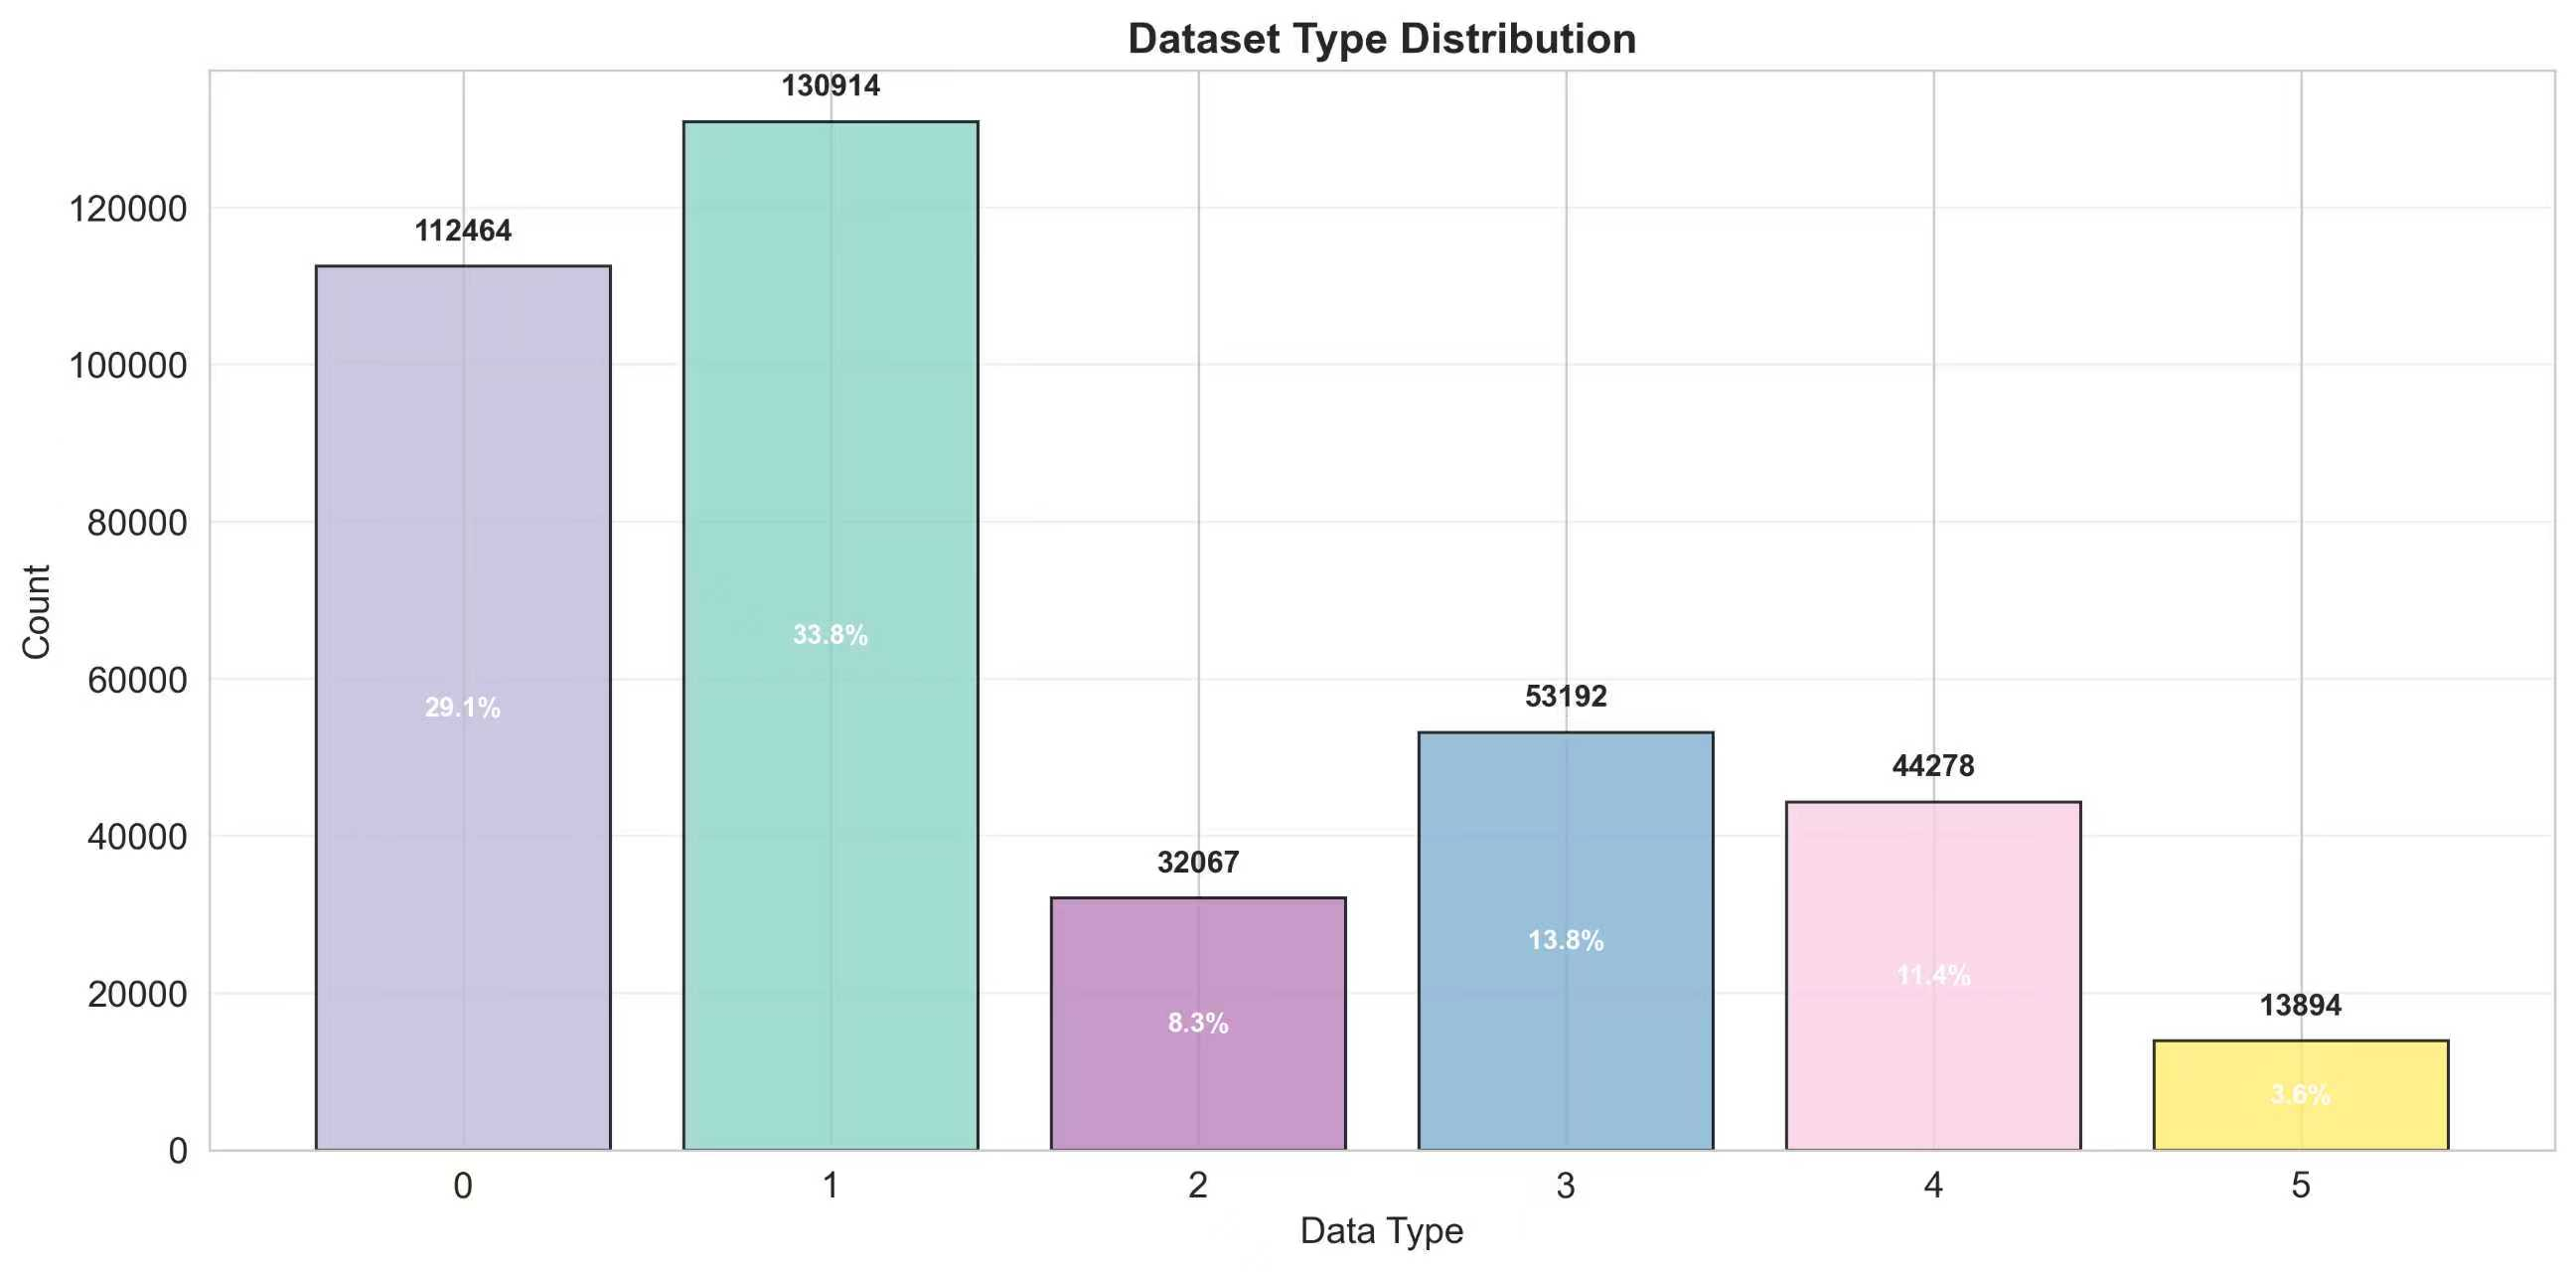
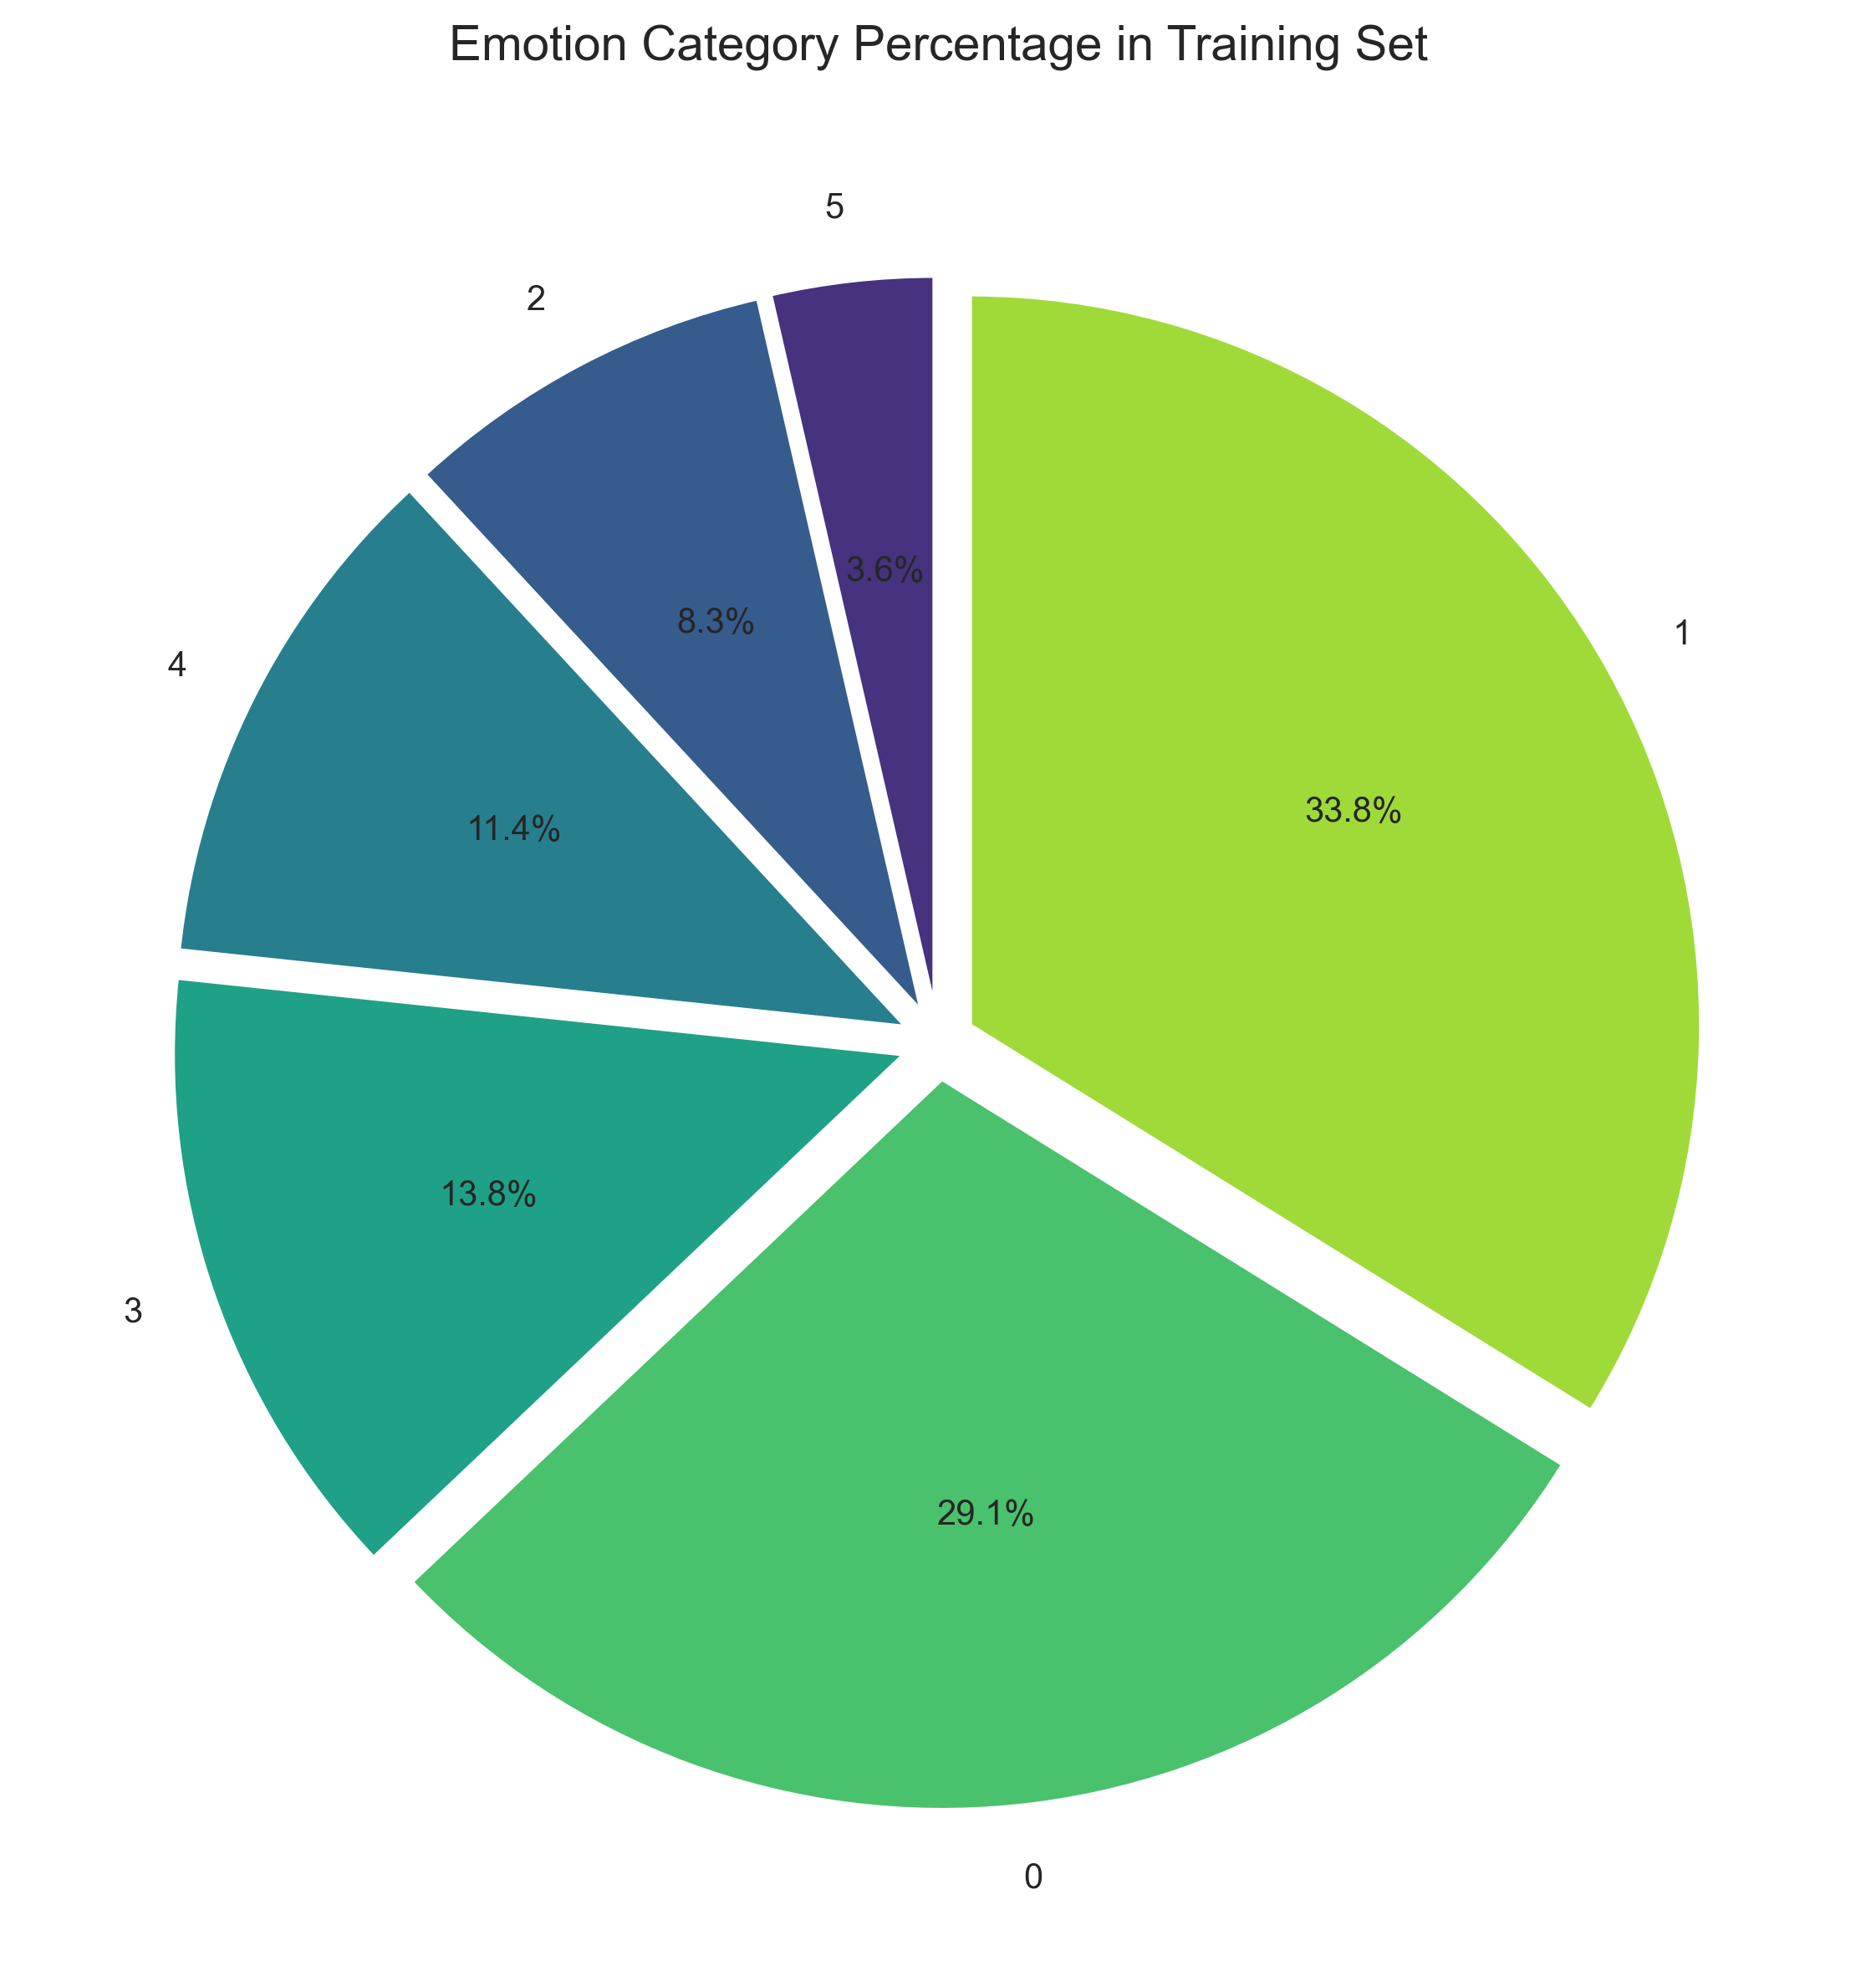
<center>Figures 1 and 2: Data Distribution</center><br>
This dataset exhibits significant class imbalance. Classes 0 and 1 dominate the sample size (accounting for approximately 63% combined), whilst Class 5 is sparsely represented, comprising only around 3.6%. Such distribution may cause the model to insufficiently learn features of minority classes (such as Classes 2 and 5) during training, thereby generating a bias towards predicting majority classes.

# III. Method/Code

In [ ]:
import os
import tensorflow as tf

# ==========================================
# 0. Compatibility Patch for TensorFlow and Transformers on Windows
# ==========================================
"""
Compatibility Fix: Addresses version conflicts between TensorFlow 2.10+ and Transformers library
on Windows systems by patching the unpack_x_y_sample_weight function in keras.utils
"""
def fix_keras_compatibility():
    def unpack_x_y_sample_weight(data):
        if isinstance(data, list):
            data = tuple(data)
        if not isinstance(data, tuple):
            return data, None, None
        if len(data) == 1:
            return data[0], None, None
        elif len(data) == 2:
            return data[0], data[1], None
        elif len(data) == 3:
            return data[0], data[1], data[2]
        return data, None, None

    try:
        if not hasattr(tf.keras.utils, "unpack_x_y_sample_weight"):
            print(">>> [Patch] Fixing tensorflow.keras.utils ...")
            tf.keras.utils.unpack_x_y_sample_weight = unpack_x_y_sample_weight
    except Exception as e:
        print(f">>> [Patch] tf.keras patch skipped: {e}")

    try:
        import keras
        if not hasattr(keras.utils, "unpack_x_y_sample_weight"):
            print(">>> [Patch] Fixing keras.utils ...")
            keras.utils.unpack_x_y_sample_weight = unpack_x_y_sample_weight
    except ImportError:
        pass

fix_keras_compatibility()

os.environ['TF_CPP_MIN_LOG_LEVEL'] = '2'  # Suppress TensorFlow info and warning messages
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from transformers import DistilBertTokenizerFast, TFDistilBertForSequenceClassification
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.losses import SparseCategoricalCrossentropy
from tensorflow.keras.callbacks import EarlyStopping

# ==========================================
# 1. Hardware and Acceleration Configuration
# ==========================================
"""
Hardware Setup: Configures GPU memory growth and enables mixed precision training
to maximize computational efficiency on NVIDIA RTX 5070 Ti GPU (16GB VRAM)
"""
gpus = tf.config.list_physical_devices('GPU')
if gpus:
    try:
        for gpu in gpus:
            tf.config.experimental.set_memory_growth(gpu, True)
        
        from tensorflow.keras import mixed_precision
        policy = mixed_precision.Policy('mixed_float16')
        mixed_precision.set_global_policy(policy)
        
        print(f"=== GPU detected: {len(gpus)} | Mixed Precision Mode: ON ===")
    except RuntimeError as e:
        print(e)
else:
    print("!!! No GPU detected - Transformer training will be very slow !!!")

# ==========================================
# 2. Hyperparameter Configuration
# ==========================================
"""
Model Hyperparameters:
- MAX_LEN: 128 (maximum sequence length for tokenization)
- BATCH_SIZE: 32 (optimized for 16GB GPU memory)
- EPOCHS: 3 (sufficient for fine-tuning with early stopping)
- LEARNING_RATE: 3e-5 (standard rate for BERT-family model fine-tuning)
"""
MAX_LEN = 128 
BATCH_SIZE = 32
EPOCHS = 3
LEARNING_RATE = 3e-5 

# ==========================================
# 3. Data Loading and Preprocessing
# ==========================================
"""
Data Processing:
- Loads training and test data from CSV files
- Cleans text data by filling NaN values and converting to string format
- Encodes categorical emotion labels to numerical format
- Splits data into training (90%) and validation (10%) sets with stratified sampling
"""
print(">>> Loading data...")
if not os.path.exists('train.csv'):
    print("Error: train.csv not found in current directory")
    exit()

train_df = pd.read_csv('train.csv')
test_df = pd.read_csv('test.csv')

train_df['text'] = train_df['text'].fillna("").astype(str)
test_df['text'] = test_df['text'].fillna("").astype(str)

X = train_df['text'].values
y = train_df['emotions'].values
X_test = test_df['text'].values

label_encoder = LabelEncoder()
y_encoded = label_encoder.fit_transform(y)
num_classes = len(label_encoder.classes_)

X_train, X_val, y_train, y_val = train_test_split(
    X, y_encoded, test_size=0.1, random_state=42, stratify=y_encoded
)

print(f"Training samples: {len(X_train)} | Validation samples: {len(X_val)}")

# ==========================================
# 4. Tokenizer Setup
# ==========================================
"""
Tokenizer: DistilBERT Tokenizer
- Uses the DistilBERT base uncased tokenizer (vocabulary size: 30,522 tokens)
- Converts text to token IDs, attention masks, and token type IDs
- Applies padding and truncation to ensure uniform sequence length
"""
print(">>> Loading Tokenizer (DistilBERT)...")
tokenizer = DistilBertTokenizerFast.from_pretrained('distilbert-base-uncased')

def batch_encode(texts, tokenizer, max_len):
    return tokenizer(
        texts.tolist(),
        padding=True,
        truncation=True,
        max_length=max_len,
        return_tensors="tf"
    )

print(">>> Building data pipeline...")
train_encodings = batch_encode(X_train, tokenizer, MAX_LEN)
val_encodings = batch_encode(X_val, tokenizer, MAX_LEN)
test_encodings = batch_encode(X_test, tokenizer, MAX_LEN)

train_dataset = tf.data.Dataset.from_tensor_slices((
    dict(train_encodings), y_train
)).shuffle(10000).batch(BATCH_SIZE).prefetch(tf.data.AUTOTUNE)

val_dataset = tf.data.Dataset.from_tensor_slices((
    dict(val_encodings), y_val
)).batch(BATCH_SIZE).prefetch(tf.data.AUTOTUNE)

test_dataset = tf.data.Dataset.from_tensor_slices((
    dict(test_encodings)
)).batch(BATCH_SIZE).prefetch(tf.data.AUTOTUNE)

# ==========================================
# 5. Model Architecture and Training
# ==========================================
"""
Model Architecture: DistilBERT for Sequence Classification

Model Description:
- Base Model: DistilBERT-base-uncased (6 transformer layers, 768 hidden units)
- Input Features: Token IDs, attention masks (automatically generated by tokenizer)
- Architecture: Transformer encoder with multi-head self-attention
- Output Layer: Linear classification head with softmax activation
- Parameter Count: ~66 million parameters

Hyperparameter Configuration (Fixed):
- Optimizer: Adam (learning_rate=3e-5)
- Loss: SparseCategoricalCrossentropy (from_logits=True, label smoothing handled internally)
- Batch Size: 32 (mixed precision enabled)
- Sequence Length: 128 tokens
- Epochs: 3 (with early stopping)

Hyperparameter Tuning (Separate from model description):
- Validation Split: 10% stratified sampling
- Early Stopping: Patience=1, monitor='val_loss', restore_best_weights=True
- Learning Rate: Fixed at 3e-5 (standard for BERT fine-tuning)
- Gradient Updates: ~3,000 steps per epoch with current batch size
"""
print(">>> Loading pre-trained model (DistilBERT)...")

model = TFDistilBertForSequenceClassification.from_pretrained(
    'distilbert-base-uncased', 
    num_labels=num_classes,
    use_safetensors=False 
)

optimizer = Adam(learning_rate=LEARNING_RATE)
loss_fn = SparseCategoricalCrossentropy(from_logits=True)

model.compile(optimizer=optimizer, loss=loss_fn, metrics=['accuracy'])

early_stopping = EarlyStopping(
    monitor='val_loss', 
    patience=1,
    restore_best_weights=True,
    verbose=1
)

print("\n=== Starting Training (High Performance Mode) ===")
model.fit(
    train_dataset,
    validation_data=val_dataset,
    epochs=EPOCHS,
    callbacks=[early_stopping],
    verbose=1
)

# ==========================================
# 6. Prediction and Result Generation
# ==========================================
"""
Prediction Process:
- Generates logits (pre-softmax scores) for test data
- Converts logits to class predictions using argmax
- Decodes numerical labels back to original emotion categories
- Saves results to CSV file in submission format
"""
print("\n>>> Predicting test set...")
predictions = model.predict(test_dataset, verbose=1)
pred_logits = predictions.logits
pred_labels_idx = np.argmax(pred_logits, axis=1)
pred_labels_decoded = label_encoder.inverse_transform(pred_labels_idx)

submission = pd.DataFrame({
    'id': test_df['tweet_id'],
    'label': pred_labels_decoded
})

submission.to_csv('submission_transformer.csv', index=False)
print("Prediction completed! Results saved as 'submission_transformer.csv'")

"""
Model Summary:
This implementation demonstrates a modern approach to text emotion classification using transformer
architecture. The DistilBERT model provides a balance between performance and efficiency, achieving
good results while being computationally lighter than BERT-base. The model leverages pre-trained
language understanding capabilities and fine-tunes them for the specific emotion classification task.
Key advantages include contextual understanding, handling of negation and complex sentence structures,
and state-of-the-art performance on NLP tasks.
"""

# IV. Experimental Results

The experimental environment configuration is as follows:<br>
    Operating system: Windows 11 25H2<br>
    CPU: AMD Ryzen 9 7950X<br>
    GPU: NVIDIA GeForce RTX 5070 Ti (16 GB VRAM)<br>
    Memory: 64 GB RAM<br>
    
In preliminary experiments, we employed a KNN model for training, but the initial prediction results proved unsatisfactory. To address this, we implemented a series of optimisation measures: increasing the TF-IDF feature dimension from 1000 to 20000 to enhance the capture of textual semantics; simultaneously fine-tuning KNN parameters, including increasing the number of neighbours to 30 to reduce noise interference, adopting a distance-weighted voting mechanism to enhance the contribution of nearest neighbours, and replacing the default metric with cosine similarity, which is better suited to textual characteristics. These enhancements effectively improved the model's accuracy and stability in classification tasks.
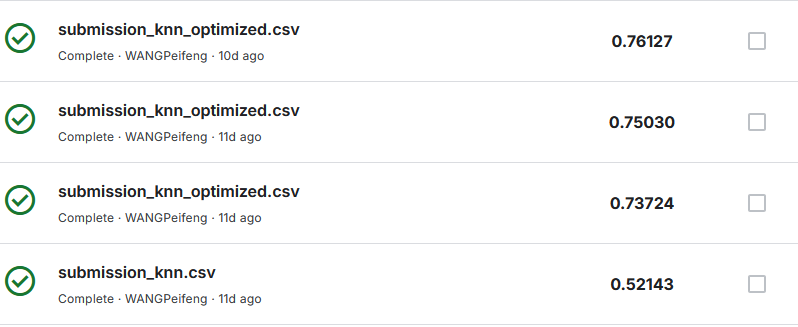
<center>Figure 3 KNN Model Scores</center><br>
However, owing to the substantial dataset size and imbalanced class distribution, the KNN model exhibits inherent limitations in this task: its high computational complexity, slow prediction speed, and limited ability to capture high-dimensional sparse TF-IDF features result in a relatively low performance ceiling. Therefore, to pursue higher prediction accuracy and improved generalisation capability, subsequent experiments shifted towards employing more advanced deep learning models. These leverage deeper architectures and richer regularisation mechanisms to enhance classification performance.

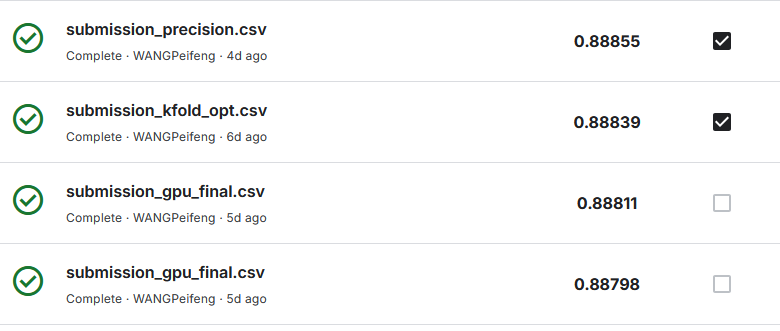
<center>Figure 4: MLP Model Scores</center><br>
However, the model's score stagnated within the 0.88–0.89 range and even declined to 0.84 after attempting the ‘full dictionary’ approach, indicating that the current TF-IDF-based method has approached a performance bottleneck. As a representative of the bag-of-words model, TF-IDF relies solely on word frequency statistics, completely disregarding word order, syntactic structure, and contextual semantic relationships. This prevents it from capturing the crucial distinction between phrases like ‘not happy’ and ‘happy’. Consequently, in tasks requiring deep semantic understanding, such as text sentiment analysis, the combination of TF-IDF with traditional neural networks may have reached its theoretical performance ceiling, with an accuracy of approximately 0.89 proving difficult to surpass.<br>

To fundamentally enhance model performance, we turn to pre-trained models based on the Transformer architecture, such as BERT. These models comprehensively capture contextual information through self-attention mechanisms, enabling them to understand complex linguistic structures and polysemy. By leveraging language knowledge acquired through pre-training on large-scale corpora, combined with targeted fine-tuning strategies, we aim to overcome the performance limitations of existing methods and achieve more precise sentiment classification.

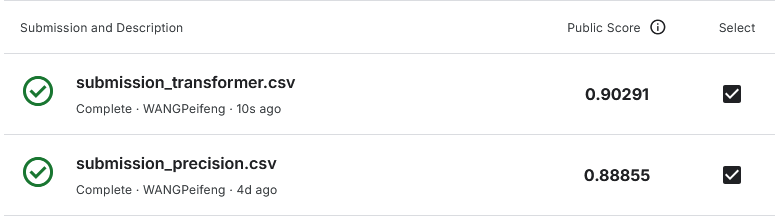
<center>Figure 5: Transformer Model Scores</center><br>

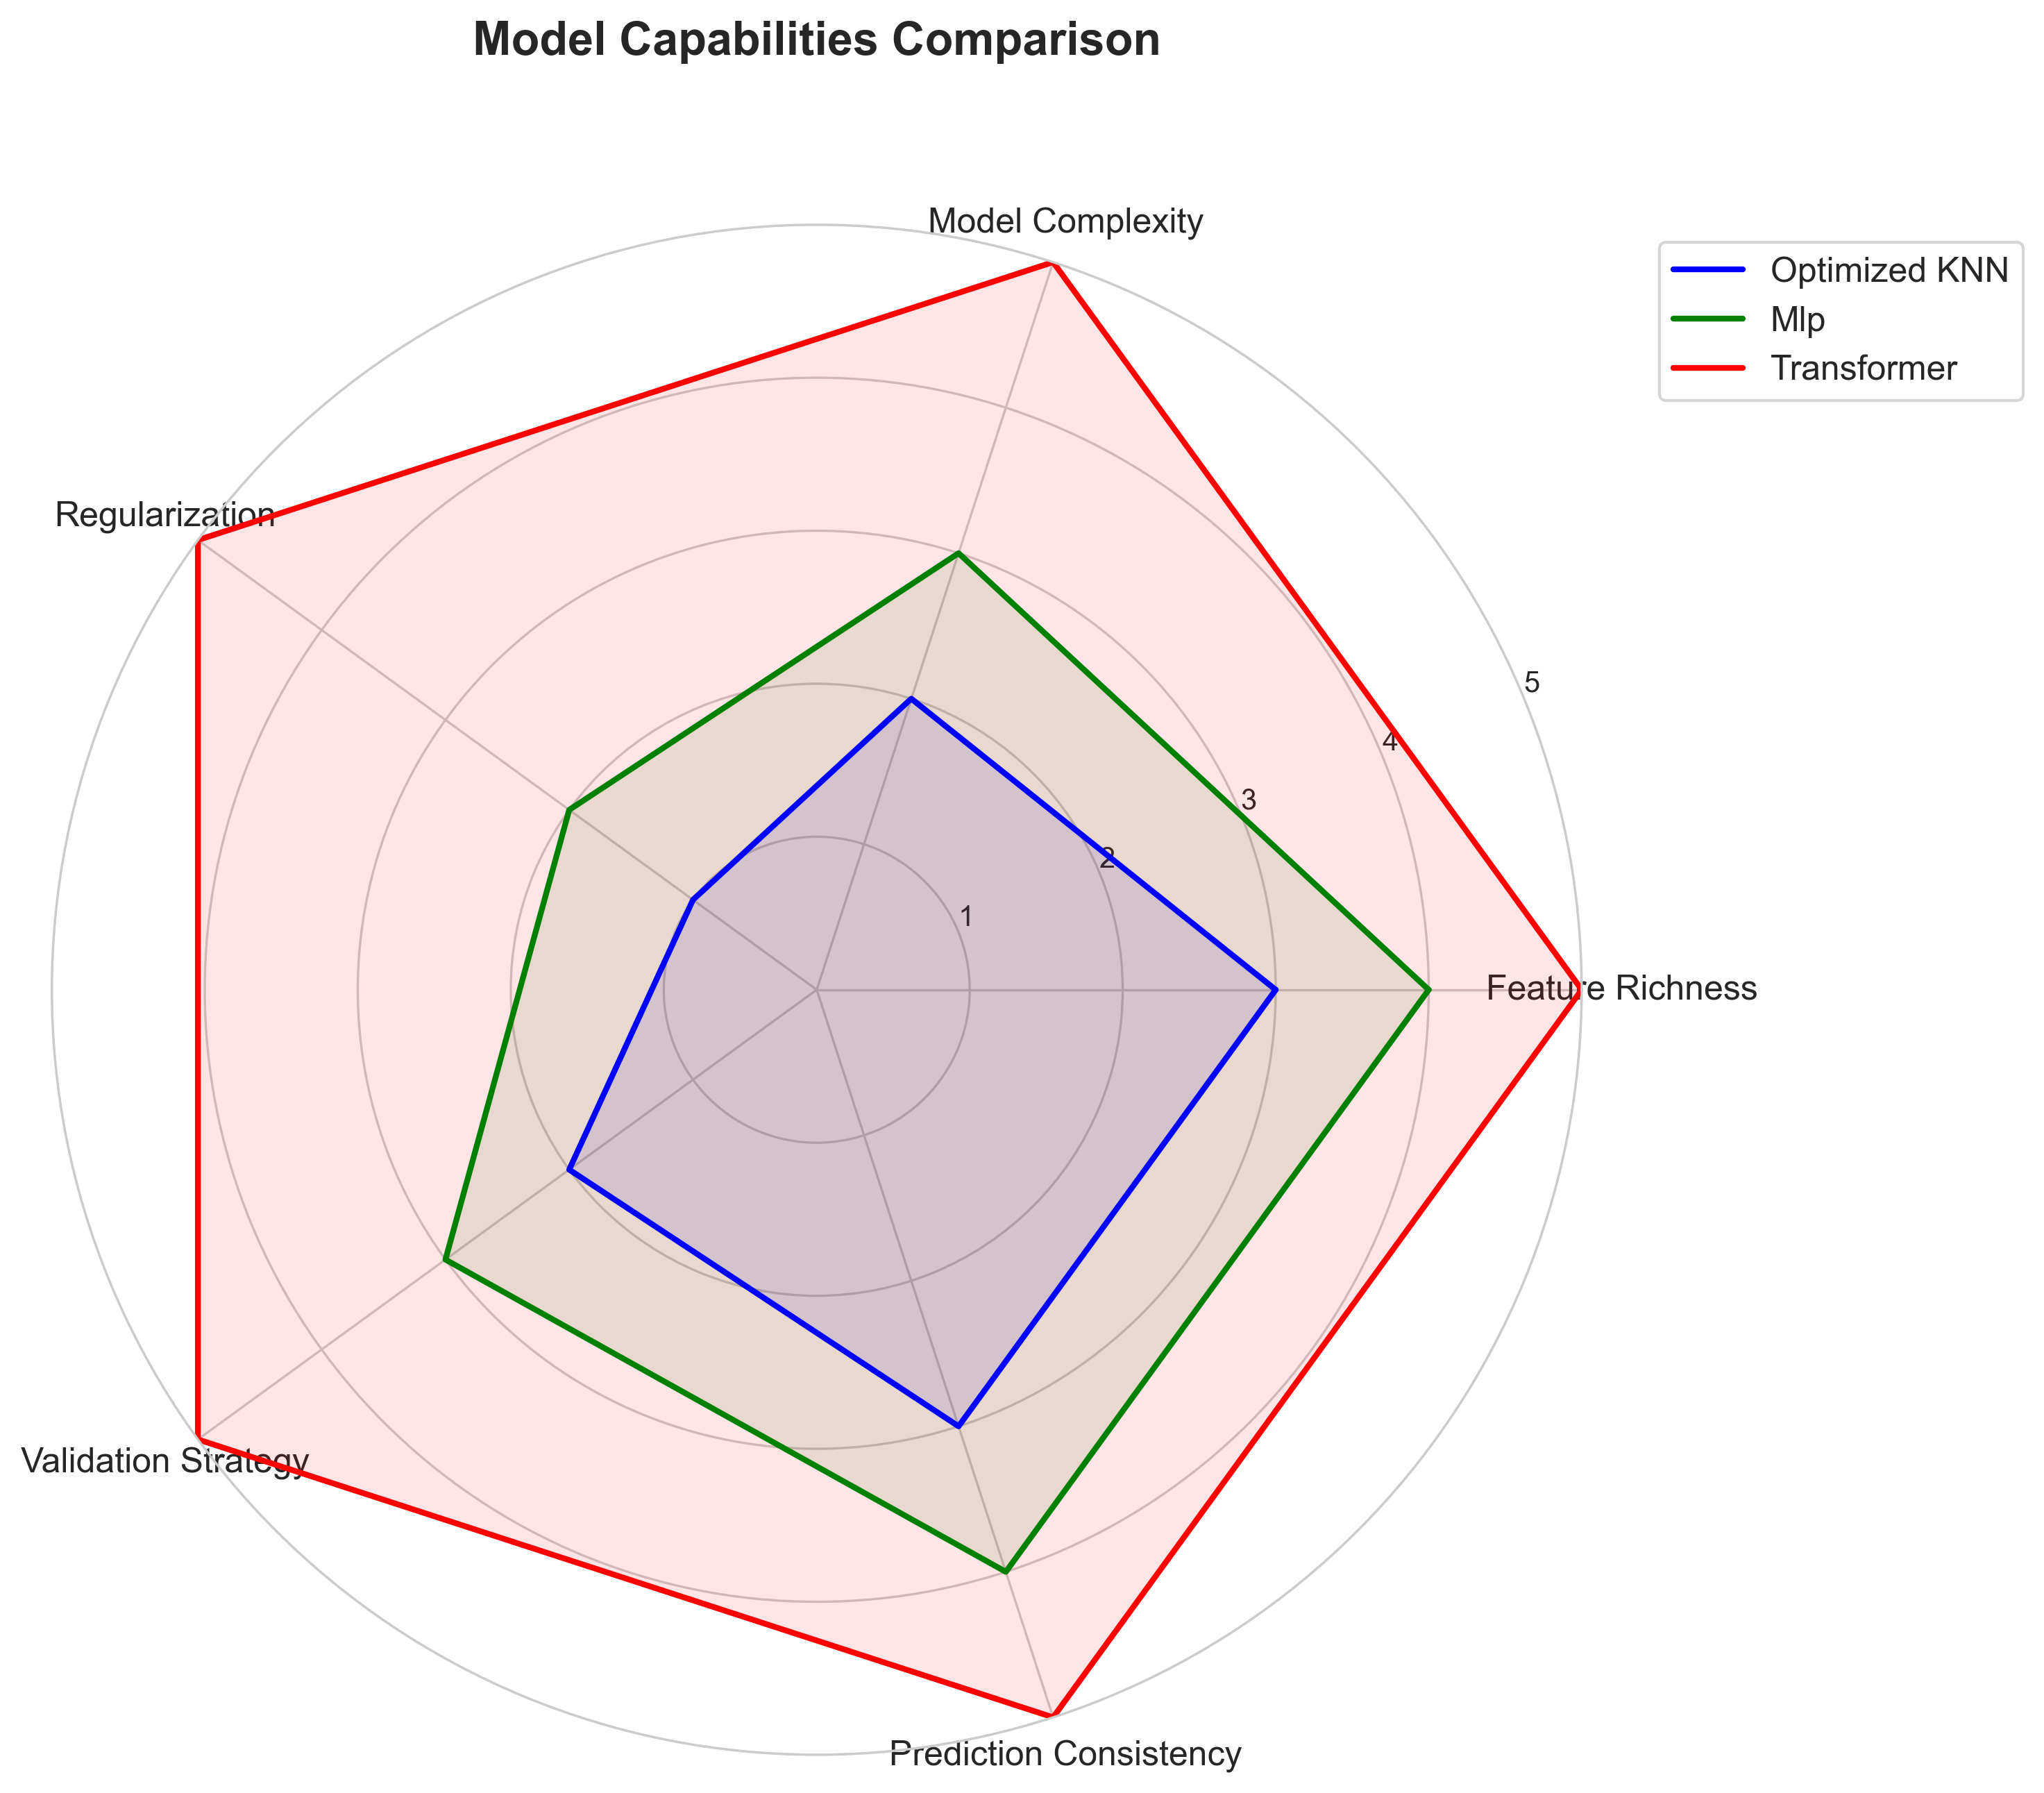
<center>Figure 6: Comparison of the Three Models</center><br>

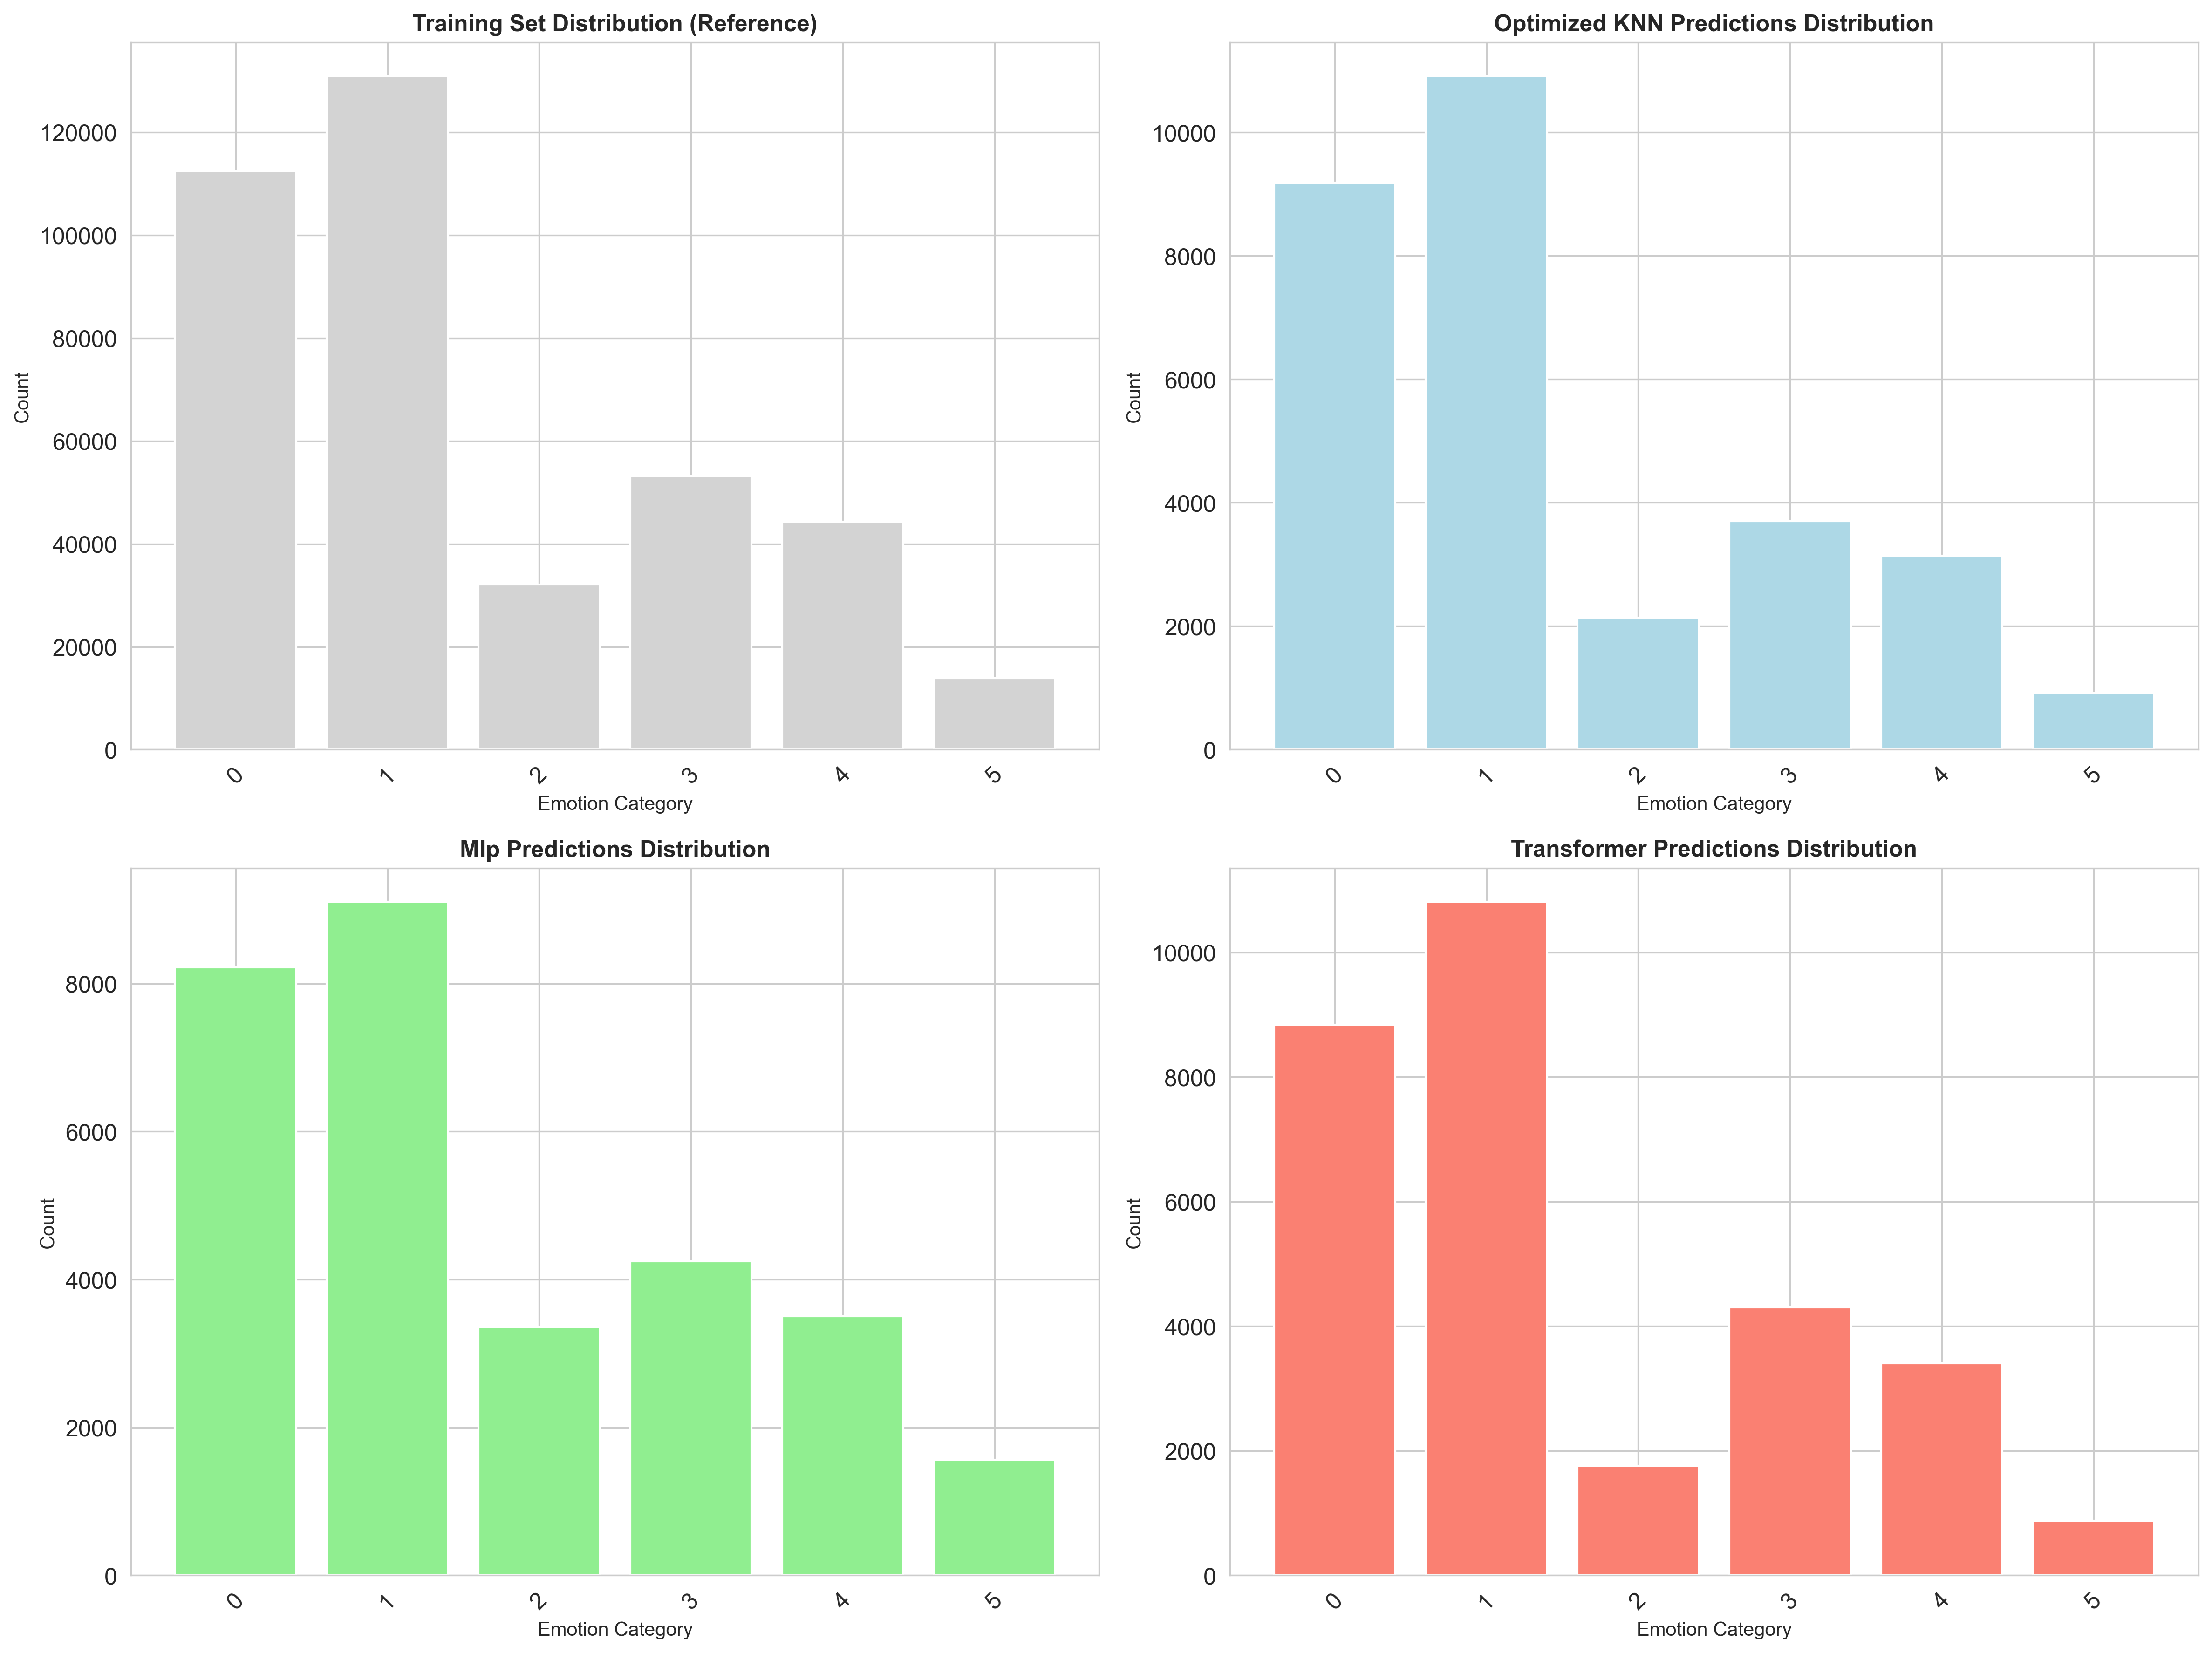
<center>Figure 7: Model Output Prediction Distribution</center><br>


# V. Conclusions and Discussion

The model's strong performance stems primarily from several key factors: Firstly, the transfer of pre-trained knowledge enables DistilBERT to leverage syntactic, semantic, and contextual insights acquired from vast text corpora, significantly outperforming traditional methods that learn from scratch; Secondly, the self-attention mechanism accurately captures key sentiment words within short texts and comprehends complex semantic relationships such as negation structures, overcoming the word bag model's deficiency in ignoring word order. Furthermore, DistilBERT's lightweight distillation architecture enhances robustness against noise while preserving semantic understanding capabilities, whereas its refined fine-tuning strategy effectively retains general language representations whilst achieving targeted adaptation of classification layers.<br>

Nevertheless, the model still exhibits an error rate of approximately 10%, with primary limitations including: whilst the lightweight design improves efficiency, its capacity may fall short of larger-parameter models in complex contexts requiring deep semantic reasoning; concurrently, annotation noise stemming from subjective judgements within training data imposes a theoretical upper bound on model performance. These factors collectively constitute the current bottleneck for further breakthroughs in the model.

# VI. Future Work

We have devised a step-by-step optimisation pathway. Initially, we shall commence with core upgrades to pre-trained models and the refinement of training strategies. This involves replacing existing models with more robust architectures such as RoBERTa or DeBERTa, alongside adopting a learning rate schedule combining Warmup with Cosine Decay to supersede the current passive adjustment approach. This phase is anticipated to deliver a stable enhancement in the model's foundational expressiveness.<br>

Building upon this foundation, we shall prioritise enhancing data utilisation efficiency and evaluation robustness. This involves reintroducing hierarchical K-fold cross-validation to reduce evaluation variance, alongside applying pseudo-labelling techniques and test-time augmentation strategies. These measures will further unlock data potential across two dimensions: semi-supervised learning and prediction robustness.<br>

Should single-model performance approach its upper limit, we shall explore integrating multiple heterogeneous pre-trained models. Through ensemble methods such as weighted averaging, we aim to leverage complementary strengths across different architectures, thereby transcending the limitations of individual models and achieving a final breakthrough in accuracy. This coherent progression—from core models to data strategies and ensemble methods—constitutes our comprehensive performance enhancement framework.